# 04 – Predictive Modeling

Train and evaluate machine learning models to predict maternal morbidity.

# **Import Data + Libraries**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from imblearn.over_sampling import SMOTE
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/Capstone/final_modeling_data.csv')
model_data = pd.DataFrame(data)
display(model_data.columns)
display(model_data.head())

Index(['mager', 'priorlive', 'priordead', 'priorterm', 'rf_cesarn', 'illb_r',
       'm_ht_in', 'bmi', 'wtgain', 'combgest', 'previs', 'cig_0', 'cig_1',
       'cig_2', 'cig_3', 'rf_pdiab', 'rf_gdiab', 'rf_phype', 'rf_ghype',
       'rf_ehype', 'rf_ppterm', 'ip_gon', 'ip_syph', 'ip_chlam', 'ip_hepb',
       'ip_hepc', 'meduc', 'lbo_rec', 'tbo_rec', 'precare', 'mracehisp_1.0',
       'mracehisp_2.0', 'mracehisp_3.0', 'mracehisp_4.0', 'mracehisp_5.0',
       'mracehisp_6.0', 'mracehisp_7.0', 'mracehisp_Unknown', 'cluster',
       'mm_mtr', 'mm_plac', 'mm_rupt', 'mm_uhyst', 'mm_aicu', 'any_morb',
       'soc_demo_risk', 'repro_risk', 'metabolic_risk', 'smoking_risk',
       'infection_risk'],
      dtype='object')

,mager,priorlive,priordead,priorterm,rf_cesarn,illb_r,m_ht_in,bmi,wtgain,combgest,...,mm_plac,mm_rupt,mm_uhyst,mm_aicu,any_morb,soc_demo_risk,repro_risk,metabolic_risk,smoking_risk,infection_risk
0,30,1.0,0.0,0.0,0.0,30.0,66.0,20.799999,4.0,38.0,...,0,0,0,0,0,1,False,0,0,0
1,28,0.0,0.0,0.0,0.0,36.0,67.0,20.400000,40.0,38.0,...,0,0,0,0,0,0,False,0,0,0
2,41,6.0,0.0,2.0,2.0,84.0,67.0,22.700001,28.0,37.0,...,0,0,0,0,0,1,True,0,0,0
3,29,2.0,0.0,0.0,0.0,49.0,61.0,26.400000,28.0,38.0,...,0,0,0,0,0,1,False,0,0,0
4,28,1.0,0.0,2.0,0.0,17.0,64.0,21.500000,31.0,39.0,...,0,0,0,0,0,0,True,0,0,0


In [ ]:
# Change dtype to int
model_data['repro_risk'] = model_data['repro_risk'].astype(int)
print(model_data['repro_risk'].info())

<class 'pandas.core.series.Series'>
RangeIndex: 3638436 entries, 0 to 3638435
Series name: repro_risk
Non-Null Count    Dtype
--------------    -----
3638436 non-null  int64
dtypes: int64(1)
memory usage: 27.8 MB
None


# **Run the Modeling Process**

## ***Full Cohort Modeling***

### *Define Outcome + Predictors for Full Cohort*

In [ ]:
#-----Define Predictors/Features for Full Cohort------#
composite_cols = ['soc_demo_risk', 'repro_risk', 'metabolic_risk', 'smoking_risk', 'infection_risk']
outcome_cols = ['mm_mtr', 'mm_plac','mm_rupt', 'mm_uhyst', 'mm_aicu', 'any_morb']

feature_vars = model_data.drop(columns = composite_cols + outcome_cols)

# Confirm Dataset for Full Cohort
display(feature_vars.columns)

Index(['mager', 'priorlive', 'priordead', 'priorterm', 'rf_cesarn', 'illb_r',
       'm_ht_in', 'bmi', 'wtgain', 'combgest', 'previs', 'cig_0', 'cig_1',
       'cig_2', 'cig_3', 'rf_pdiab', 'rf_gdiab', 'rf_phype', 'rf_ghype',
       'rf_ehype', 'rf_ppterm', 'ip_gon', 'ip_syph', 'ip_chlam', 'ip_hepb',
       'ip_hepc', 'meduc', 'lbo_rec', 'tbo_rec', 'precare', 'mracehisp_1.0',
       'mracehisp_2.0', 'mracehisp_3.0', 'mracehisp_4.0', 'mracehisp_5.0',
       'mracehisp_6.0', 'mracehisp_7.0', 'mracehisp_Unknown', 'cluster'],
      dtype='object')

In [ ]:
# Morbidity Distribution
display(model_data['any_morb'].value_counts(normalize = True) * 100)

,proportion
any_morb,
0,98.470854
1,1.529146


### *Define the Evaluation Function*

In [ ]:
def model_eval(y_test, pred, prob):

  # Classification Report
  report = pd.DataFrame(classification_report(y_test, pred, output_dict = True)).T
  print('Classification Report:')
  display(report.round(3))

  # Confusion Matrix
  cm = confusion_matrix(y_test, pred)

  plt.figure(figsize = (8, 6))
  sns.heatmap(cm, annot = True, fmt = ',', cmap = 'Blues',
              xticklabels = ['No Morbidity', 'Morbidity'],
              yticklabels = ['No Morbidity', 'Morbidity'])
  plt.xlabel('Predicted')
  plt.ylabel('Actual')
  plt.title('\nConfusion Matrix')
  plt.show()

  # Model Performance Metrics
  results = pd.DataFrame({
      'Accuracy': [accuracy_score(y_test, pred)],
      'Precision': [precision_score(y_test, pred)],
      'Recall': [recall_score(y_test, pred)],
      'F1': [f1_score(y_test, pred)],
      'ROC-AUC': [roc_auc_score(y_test, prob)],
      'PR-AUC': [average_precision_score(y_test, prob)]
  })

  print('\nModel Performance Metrics:')

  return results.round(3)

### ***Full Cohort Model Process***

#### *Train/Test Split + Scaling*

In [ ]:
#-----Define Target + Features-----#
X = feature_vars
y = model_data['any_morb']

#-----Train/Test Split-----#
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

#-----Scaling the Data-----#
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#-----Apply SMOTE-----#
smote = SMOTE(random_state = 42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

#### ***Logistic Regression***

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


'Best Threshold:'

np.float64(0.99)

Classification Report:


,precision,recall,f1-score,support
0,0.986,0.899,0.940,716561.000
1,0.027,0.178,0.046,11127.000
accuracy,0.888,0.888,0.888,0.888
macro avg,0.506,0.538,0.493,727688.000
weighted avg,0.971,0.888,0.927,727688.000


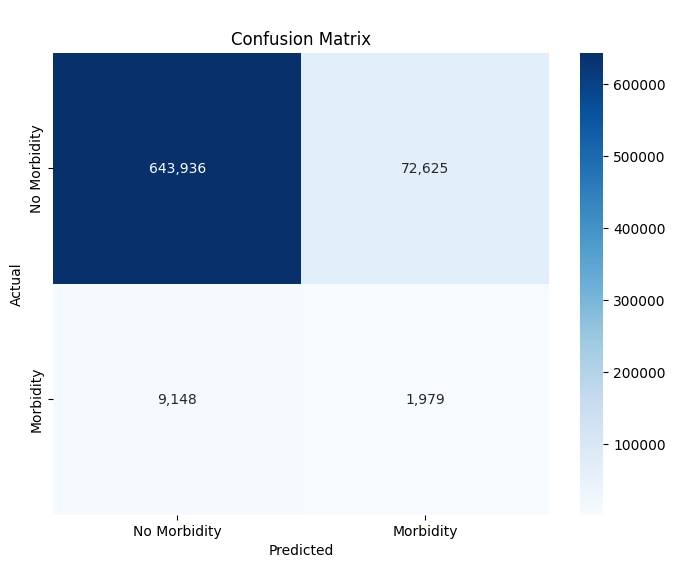


Model Performance Metrics:


,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,0.888,0.027,0.178,0.046,0.593,0.021


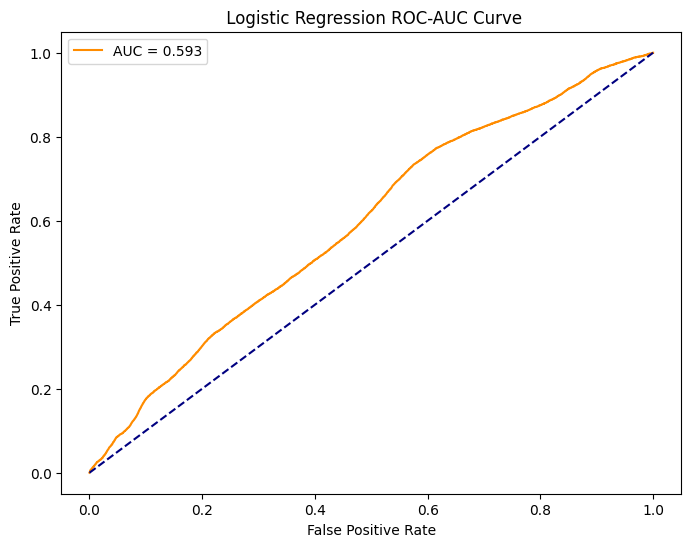

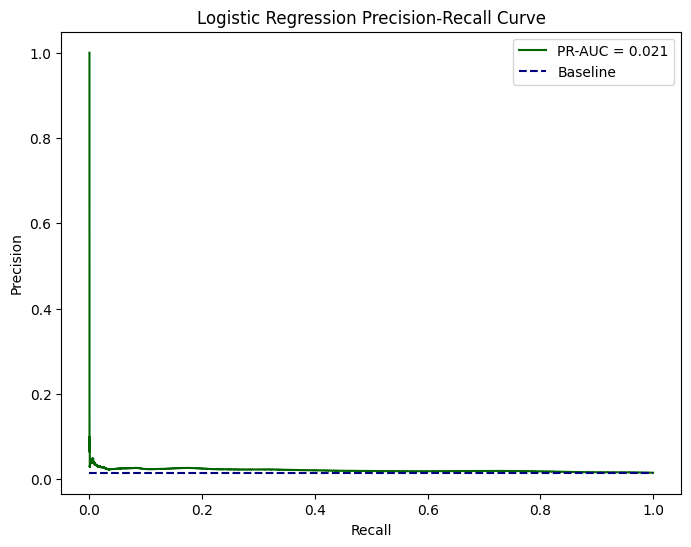

In [ ]:
full_logreg_model = LogisticRegression(
    random_state = 42,
    class_weight = 'balanced',
    max_iter = 3000,
    solver = 'lbfgs',
    C = 1
)

full_logreg_model.fit(X_train, y_train)
full_logreg_prob = full_logreg_model.predict_proba(X_test_scaled)[:,1]

#-----Threshold Tuning-----#
precision, recall, thresholds = precision_recall_curve(y_test, full_logreg_prob)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
best_threshold = thresholds[np.argmax(f1_scores)]
display("Best Threshold:", round(best_threshold, 3))
full_logreg_pred = (full_logreg_prob >= best_threshold).astype(int)

#-----Display the Results-----#
full_logreg_model_results = model_eval(y_test, full_logreg_pred, full_logreg_prob)
display(full_logreg_model_results)

#-----ROC Curve-----#
fpr, tpr, _ = roc_curve(y_test, full_logreg_prob)
auc = roc_auc_score(y_test, full_logreg_prob)
plt.figure(figsize = (8, 6))
plt.plot(fpr, tpr, color = 'darkorange', label = f'AUC = {auc:.3f}')
plt.plot([0, 1], [0, 1], color = 'navy', linestyle = '--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(' Logistic Regression ROC-AUC Curve')
plt.legend()
plt.show()

#-----PR Curve-----#
precision, recall, _ = precision_recall_curve(y_test, full_logreg_prob)
pr_auc = average_precision_score(y_test, full_logreg_prob)

plt.figure(figsize = (8, 6))
plt.plot(recall, precision, color = 'darkgreen', label = f'PR-AUC = {pr_auc:.3f}')

# Baseline (prevalence line)
baseline = y_test.mean()
plt.hlines(y = baseline, xmin = 0, xmax = 1, colors = 'navy', linestyles = '--', label = 'Baseline')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Logistic Regression Precision-Recall Curve')
plt.legend()
plt.show()

#### ***Random Forest***

'Best Threshold (RF):'

np.float64(0.558)

Classification Report:


,precision,recall,f1-score,support
0,0.986,0.943,0.964,716561.00
1,0.035,0.132,0.055,11127.00
accuracy,0.930,0.930,0.930,0.93
macro avg,0.510,0.537,0.509,727688.00
weighted avg,0.971,0.930,0.950,727688.00


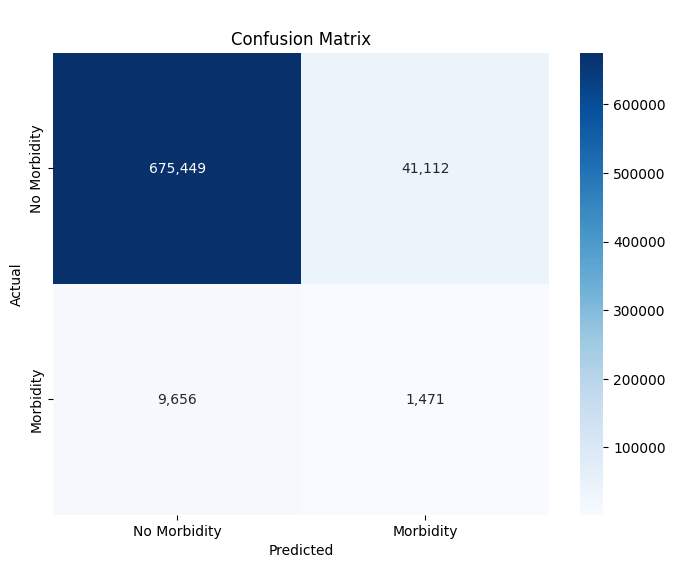


Model Performance Metrics:


,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,0.93,0.035,0.132,0.055,0.632,0.026


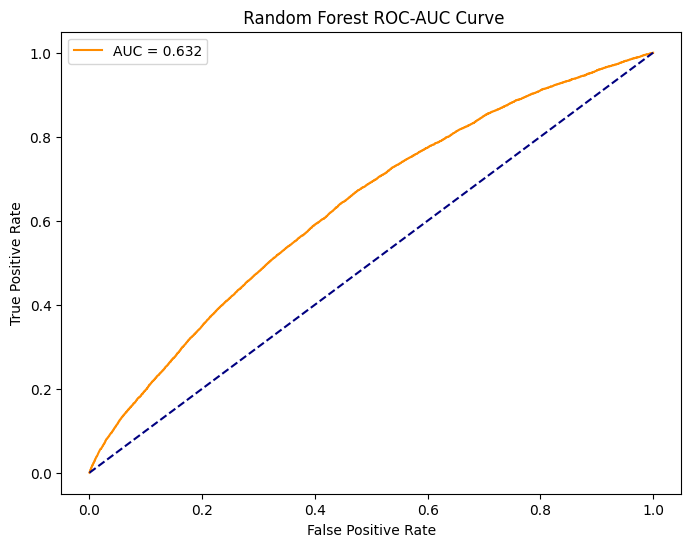

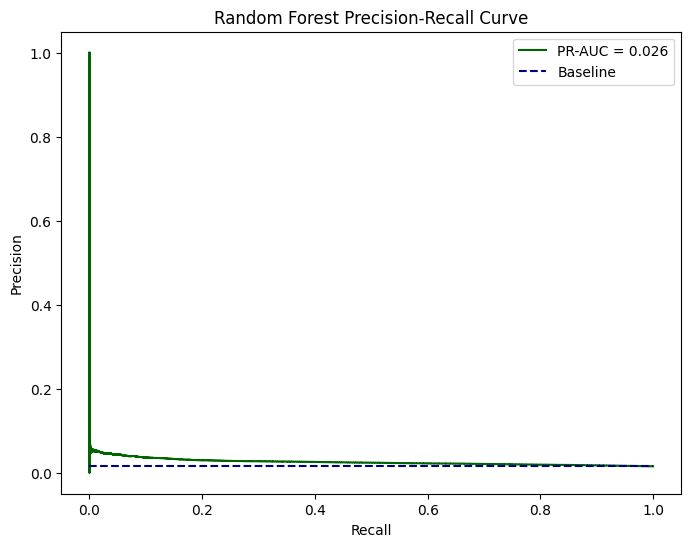

In [ ]:
full_rf_model = RandomForestClassifier(
    n_estimators = 300,
    max_depth = 10,
    min_samples_split = 5,
    random_state = 42,
    n_jobs = -1
)

full_rf_model.fit(X_train_smote, y_train_smote)
full_rf_prob = full_rf_model.predict_proba(X_test)[:,1]

#-----Threshold Tuning-----#
precision, recall, thresholds = precision_recall_curve(y_test, full_rf_prob)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
best_threshold = thresholds[np.argmax(f1_scores)]
display("Best Threshold (RF):", round(best_threshold, 3))
full_rf_pred = (full_rf_prob >= best_threshold).astype(int)

full_rf_model_results = model_eval(y_test, full_rf_pred, full_rf_prob)

#-----Display the Results-----#
display(full_rf_model_results)

#-----ROC Curve-----#
fpr, tpr, _ = roc_curve(y_test, full_rf_prob)
auc = roc_auc_score(y_test, full_rf_prob)
plt.figure(figsize = (8, 6))
plt.plot(fpr, tpr, color = 'darkorange', label = f'AUC = {auc:.3f}')
plt.plot([0, 1], [0, 1], color = 'navy', linestyle = '--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(' Random Forest ROC-AUC Curve')
plt.legend()
plt.show()

#-----PR Curve-----#
precision, recall, _ = precision_recall_curve(y_test, full_rf_prob)
pr_auc = average_precision_score(y_test, full_rf_prob)

plt.figure(figsize = (8, 6))
plt.plot(recall, precision, color = 'darkgreen', label = f'PR-AUC = {pr_auc:.3f}')

# Baseline (prevalence line)
baseline = y_test.mean()
plt.hlines(y = baseline, xmin = 0, xmax = 1, colors = 'navy', linestyles = '--', label = 'Baseline')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Random Forest Precision-Recall Curve')
plt.legend()
plt.show()

#### ***XGBoost***

np.float64(64.395)

'Best Threshold (RF):'

np.float32(0.669)

Classification Report:


,precision,recall,f1-score,support
0,0.987,0.936,0.961,716561.000
1,0.042,0.183,0.069,11127.000
accuracy,0.924,0.924,0.924,0.924
macro avg,0.514,0.559,0.515,727688.000
weighted avg,0.972,0.924,0.947,727688.000


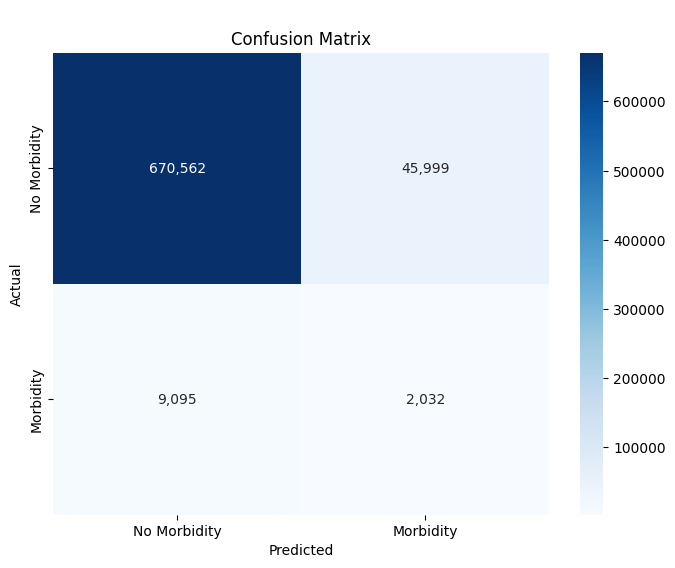


Model Performance Metrics:


,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,0.924,0.042,0.183,0.069,0.676,0.032


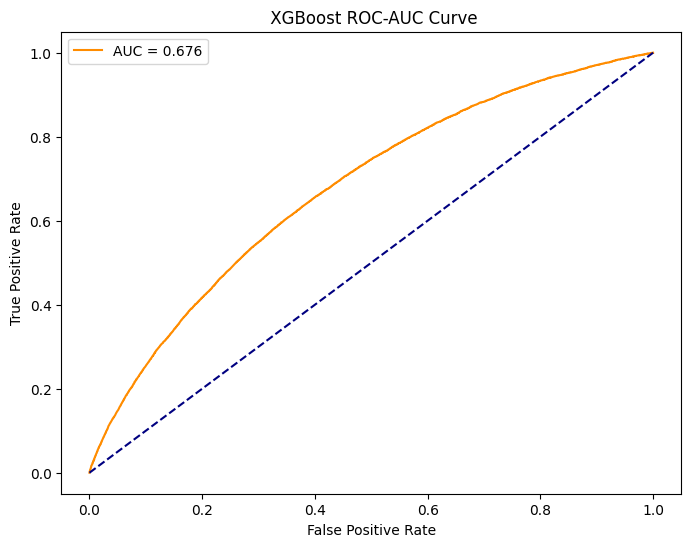

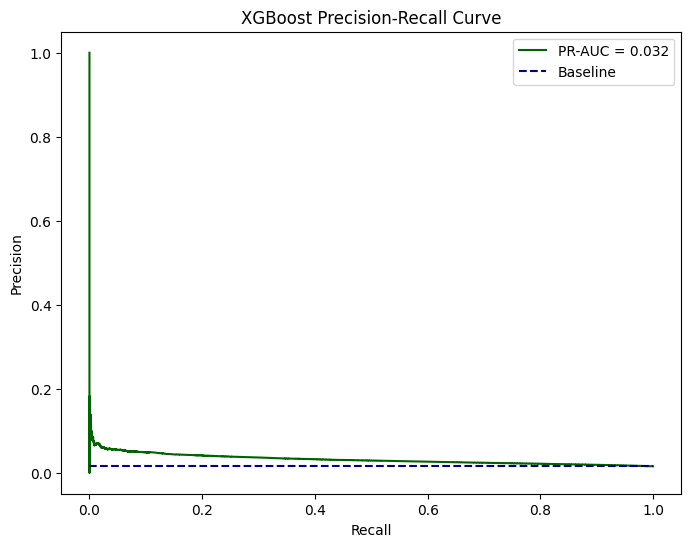

In [ ]:
#-----Compute scale-pos_weight-----#
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos
display(scale_pos_weight.round(3))

full_xgb_model = XGBClassifier(
    n_estimators = 200,
    max_depth=4,
    learning_rate=0.03,
    random_state=42,
    scale_pos_weight = scale_pos_weight,
    eval_metric='logloss'
)

full_xgb_model.fit(X_train, y_train)
full_xgb_prob = full_xgb_model.predict_proba(X_test)[:,1]

#-----Threshold Tuning-----#
precision, recall, thresholds = precision_recall_curve(y_test, full_xgb_prob)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
best_threshold = thresholds[np.argmax(f1_scores)]
display("Best Threshold (RF):", round(best_threshold, 3))
full_xgb_pred = (full_xgb_prob >= best_threshold).astype(int)

full_xgb_model_results = model_eval(y_test, full_xgb_pred, full_xgb_prob)

#-----Display the Results-----#
display(full_xgb_model_results)

#-----ROC Curve-----#
fpr, tpr, _ = roc_curve(y_test, full_xgb_prob)
auc = roc_auc_score(y_test, full_xgb_prob)
plt.figure(figsize = (8, 6))
plt.plot(fpr, tpr, color = 'darkorange', label = f'AUC = {auc:.3f}')
plt.plot([0, 1], [0, 1], color = 'navy', linestyle = '--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(' XGBoost ROC-AUC Curve')
plt.legend()
plt.show()

#-----PR Curve-----#
precision, recall, _ = precision_recall_curve(y_test, full_xgb_prob)
pr_auc = average_precision_score(y_test, full_xgb_prob)

plt.figure(figsize = (8, 6))
plt.plot(recall, precision, color = 'darkgreen', label = f'PR-AUC = {pr_auc:.3f}')

# Baseline (prevalence line)
baseline = y_test.mean()
plt.hlines(y = baseline, xmin = 0, xmax = 1, colors = 'navy', linestyles = '--', label = 'Baseline')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('XGBoost Precision-Recall Curve')
plt.legend()
plt.show()

#### *LightGBM*

np.float64(64.395)

[LightGBM] [Info] Number of positive: 44510, number of negative: 2866238
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.215854 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 993
[LightGBM] [Info] Number of data points in the train set: 2910748, number of used features: 39
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.015292 -> initscore=-4.165042
[LightGBM] [Info] Start training from score -4.165042


'Best Threshold (RF):'

np.float32(0.669)

Classification Report:


,precision,recall,f1-score,support
0,0.987,0.936,0.961,716561.000
1,0.042,0.183,0.069,11127.000
accuracy,0.924,0.924,0.924,0.924
macro avg,0.514,0.559,0.515,727688.000
weighted avg,0.972,0.924,0.947,727688.000


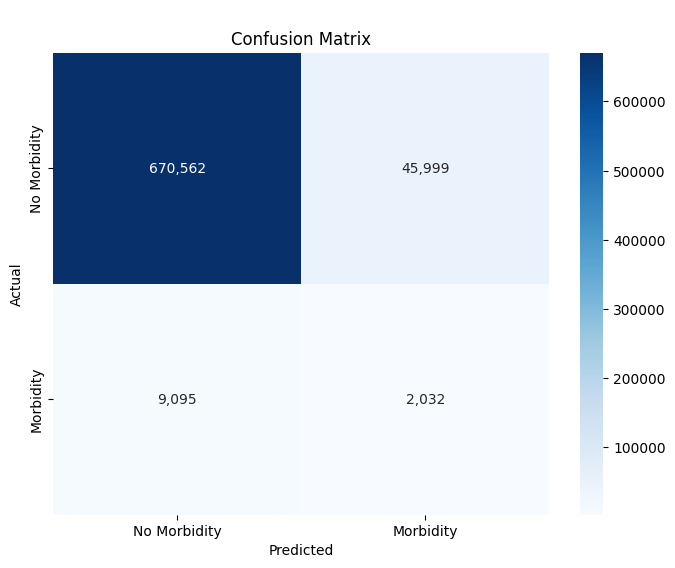


Model Performance Metrics:


,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,0.924,0.042,0.183,0.069,0.682,0.033


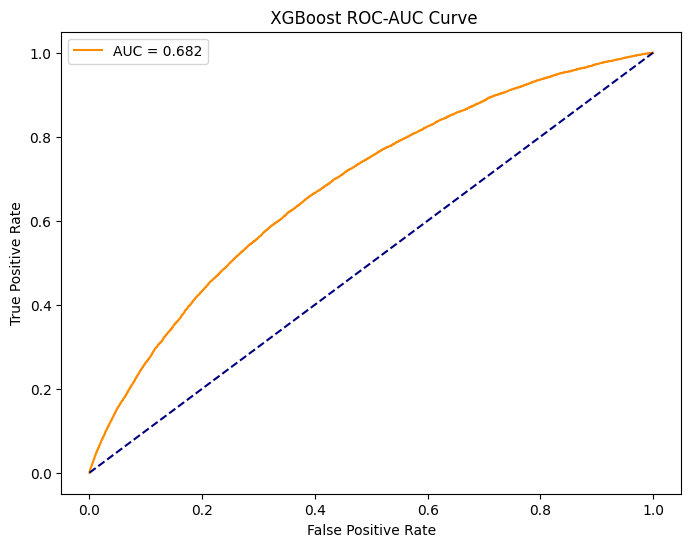

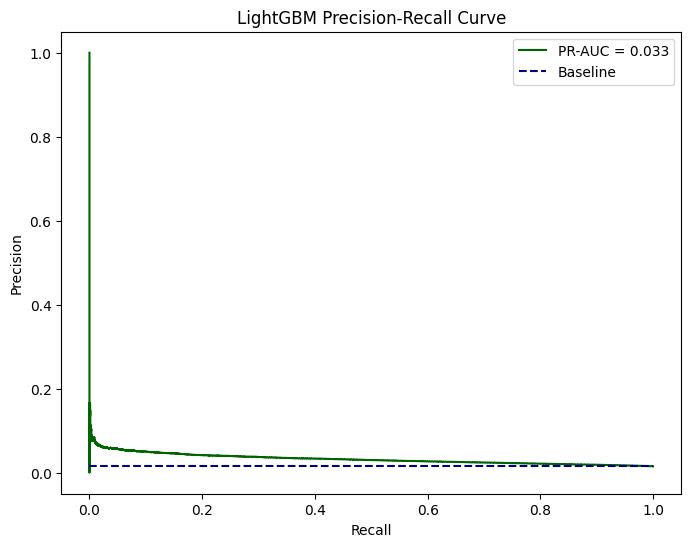

In [ ]:
#-----Compute scale-pos_weight-----#
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos
display(scale_pos_weight.round(3))

full_lgbm_model = LGBMClassifier(
    n_estimators = 200,
    learning_rate = 0.03,
    scale_pos_weight = scale_pos_weight,
    random_state = 42
)

full_lgbm_model.fit(X_train, y_train)
full_lgbm_prob = full_lgbm_model.predict_proba(X_test)[:,1]

#-----Threshold Tuning-----#
precision, recall, thresholds = precision_recall_curve(y_test, full_xgb_prob)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
best_threshold = thresholds[np.argmax(f1_scores)]
display("Best Threshold (RF):", round(best_threshold, 3))
full_lgbm_pred = (full_lgbm_prob >= best_threshold).astype(int)

full_lgbm_model_results = model_eval(y_test, full_lgbm_pred, full_lgbm_prob)

#-----Display the Results-----#
display(full_lgbm_model_results)

#-----ROC Curve-----#
fpr, tpr, _ = roc_curve(y_test, full_lgbm_prob)
auc = roc_auc_score(y_test, full_lgbm_prob)
plt.figure(figsize = (8, 6))
plt.plot(fpr, tpr, color = 'darkorange', label = f'AUC = {auc:.3f}')
plt.plot([0, 1], [0, 1], color = 'navy', linestyle = '--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(' XGBoost ROC-AUC Curve')
plt.legend()
plt.show()

#-----PR Curve-----#
precision, recall, _ = precision_recall_curve(y_test, full_lgbm_prob)
pr_auc = average_precision_score(y_test, full_lgbm_prob)

plt.figure(figsize = (8, 6))
plt.plot(recall, precision, color = 'darkgreen', label = f'PR-AUC = {pr_auc:.3f}')

# Baseline (prevalence line)
baseline = y_test.mean()
plt.hlines(y = baseline, xmin = 0, xmax = 1, colors = 'navy', linestyles = '--', label = 'Baseline')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('LightGBM Precision-Recall Curve')
plt.legend()
plt.show()

#### ***Compare All Full Cohort Results***

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate_model(y_test, pred, prob):
    return {
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "AUC": roc_auc_score(y_test, prob),
        "PR-AUC": average_precision_score(y_test, prob)
    }

log_results = evaluate_model(y_test, full_logreg_pred, full_logreg_prob)
rf_results = evaluate_model(y_test, full_rf_pred, full_rf_prob)
xgb_results = evaluate_model(y_test, full_xgb_pred, full_xgb_prob)
lgbm_results = evaluate_model(y_test, full_lgbm_pred, full_lgbm_prob)

results_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost", "LightGBM"],
    "Accuracy": [log_results["Accuracy"], rf_results["Accuracy"], xgb_results["Accuracy"], lgbm_results["Accuracy"]],
    "Precision": [log_results["Precision"], rf_results["Precision"], xgb_results["Precision"], lgbm_results["Precision"]],
    "Recall": [log_results["Recall"], rf_results["Recall"], xgb_results["Recall"], lgbm_results["Recall"]],
    "F1": [log_results["F1"], rf_results["F1"], xgb_results["F1"], lgbm_results["F1"]],
    "AUC": [log_results["AUC"], rf_results["AUC"], xgb_results["AUC"], lgbm_results["AUC"]],
    "PR-AUC": [log_results["PR-AUC"], rf_results["PR-AUC"], xgb_results["PR-AUC"], lgbm_results["PR-AUC"]]
})

print(f'Performance Results for Full Cohort:')
display(results_df.round(3))

Performance Results for Full Cohort:


,Model,Accuracy,Precision,Recall,F1,AUC,PR-AUC
0,Logistic Regression,0.888,0.027,0.178,0.046,0.593,0.021
1,Random Forest,0.930,0.035,0.132,0.055,0.632,0.026
2,XGBoost,0.924,0.042,0.183,0.069,0.676,0.032
3,LightGBM,0.924,0.042,0.183,0.069,0.682,0.033


## ***Cluster-Stratified Model Process***

In [ ]:
stratified_feature_vars = model_data.drop(columns = composite_cols + outcome_cols + ['cluster'])
display(stratified_feature_vars.columns)

Index(['mager', 'priorlive', 'priordead', 'priorterm', 'rf_cesarn', 'illb_r',
       'm_ht_in', 'bmi', 'wtgain', 'combgest', 'previs', 'cig_0', 'cig_1',
       'cig_2', 'cig_3', 'rf_pdiab', 'rf_gdiab', 'rf_phype', 'rf_ghype',
       'rf_ehype', 'rf_ppterm', 'ip_gon', 'ip_syph', 'ip_chlam', 'ip_hepb',
       'ip_hepc', 'meduc', 'lbo_rec', 'tbo_rec', 'precare', 'mracehisp_1.0',
       'mracehisp_2.0', 'mracehisp_3.0', 'mracehisp_4.0', 'mracehisp_5.0',
       'mracehisp_6.0', 'mracehisp_7.0', 'mracehisp_Unknown'],
      dtype='object')

### *Stratified Logistic Regression*

In [ ]:
strat_lr_cluster_results = []

for cluster in sorted(model_data['cluster'].unique()):

    print(f"\n===== CLUSTER {cluster} =====")

    # Subset data
    cluster_data = model_data[model_data['cluster'] == cluster]

    # Define predictors and outcome
    X = cluster_data[stratified_feature_vars.columns]
    y = cluster_data['any_morb']

    # Check number of positive cases
    print("Total Samples:", len(cluster_data))
    print("Positive Cases:", int(y.sum()))

    if y.sum() < 20:
        print("Too few positive cases — skipping cluster")
        continue

    #-----Train + Test Split-----#
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        stratify=y,
        random_state=42
    )

    #-----Logistic Regression Model-----#
    strat_lg_model = LogisticRegression(
        random_state = 42,
        class_weight = 'balanced',
        max_iter = 3000,
        solver = 'lbfgs',
        C = 1
    )

    strat_lg_model.fit(X_train, y_train)
    prob = strat_lg_model.predict_proba(X_test)[:, 1]

    #-----Threshold Tuning-----#
    precision, recall, thresholds = precision_recall_curve(y_test, prob)

    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
    best_threshold = thresholds[np.argmax(f1_scores)]

    print("Best Threshold:", round(best_threshold, 3))

    pred = (prob >= best_threshold).astype(int)

    #-----Model Evaluation-----#
    results = {
        "Cluster": cluster,
        "Total Cases": len(cluster_data),
        "Morb Cases": int(y.sum()),
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "AUC": roc_auc_score(y_test, prob),
        "PR-AUC": average_precision_score(y_test, prob)
    }

    strat_lr_cluster_results.append(results)

#-----Final Results Table-----#

strat_lr_cluster_results_df = pd.DataFrame(strat_lr_cluster_results)

print("\n===== LOGREG CLUSTER RESULTS =====")
display(strat_lr_cluster_results_df.round(3))


===== CLUSTER 0 =====
Total Samples: 595862
Positive Cases: 7579
Best Threshold: 0.784

===== CLUSTER 1 =====
Total Samples: 1193373
Positive Cases: 15406


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Best Threshold: 0.688

===== CLUSTER 2 =====
Total Samples: 1566805
Positive Cases: 27808
Best Threshold: 0.631

===== CLUSTER 3 =====
Total Samples: 282396
Positive Cases: 4844
Best Threshold: 0.628

===== LOGREG CLUSTER RESULTS =====


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Cluster,Total Cases,Morb Cases,Accuracy,Precision,Recall,F1,AUC,PR-AUC
0,0,595862,7579,0.968,0.068,0.121,0.087,0.665,0.034
1,1,1193373,15406,0.959,0.034,0.080,0.048,0.630,0.022
2,2,1566805,27808,0.897,0.039,0.202,0.065,0.655,0.031
3,3,282396,4844,0.893,0.042,0.237,0.071,0.650,0.031


### *Stratified Random Forest*

In [ ]:
strat_rf_cluster_results = []

for cluster in sorted(model_data['cluster'].unique()):

    print(f"\n===== CLUSTER {cluster} =====")

    # Subset data
    cluster_data = model_data[model_data['cluster'] == cluster]

    # Define predictors and outcome
    X = cluster_data[stratified_feature_vars.columns]
    y = cluster_data['any_morb']

    # Check number of positive cases
    print("Total Samples:", len(cluster_data))
    print("Positive Cases:", int(y.sum()))

    if y.sum() < 20:
        print("Too few positive cases — skipping cluster")
        continue



    #-----Train + Test Split-----#
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        stratify=y,
        random_state=42
    )

    #-----Apply SMOTE-----#
    smote = SMOTE(random_state = 42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

    #-----Rnadom Forest Model-----#
    strat_rf_model = RandomForestClassifier(
        n_estimators = 300,
        max_depth = 10,
        min_samples_split = 5,
        random_state = 42,
        n_jobs = -1
    )

    strat_rf_model.fit(X_train, y_train)
    prob = strat_rf_model.predict_proba(X_test)[:, 1]

    #-----Threshold Tuning-----#
    precision, recall, thresholds = precision_recall_curve(y_test, prob)

    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
    best_threshold = thresholds[np.argmax(f1_scores)]

    print("Best Threshold:", round(best_threshold, 3))

    pred = (prob >= best_threshold).astype(int)

    #-----Model Evaluation-----#
    results = {
        "Cluster": cluster,
        "Total Cases": len(cluster_data),
        "Morb Cases": int(y.sum()),
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "AUC": roc_auc_score(y_test, prob),
        "PR-AUC": average_precision_score(y_test, prob)
    }

    strat_rf_cluster_results.append(results)

#-----Final Results Table-----#

strat_rf_cluster_results_df = pd.DataFrame(strat_rf_cluster_results)

print("\n===== RANDOM FOREST CLUSTER RESULTS =====")
display(strat_rf_cluster_results_df.round(3))


===== CLUSTER 0 =====
Total Samples: 595862
Positive Cases: 7579
Best Threshold: 0.04

===== CLUSTER 1 =====
Total Samples: 1193373
Positive Cases: 15406
Best Threshold: 0.026

===== CLUSTER 2 =====
Total Samples: 1566805
Positive Cases: 27808
Best Threshold: 0.032

===== CLUSTER 3 =====
Total Samples: 282396
Positive Cases: 4844
Best Threshold: 0.036

===== RANDOM FOREST CLUSTER RESULTS =====


,Cluster,Total Cases,Morb Cases,Accuracy,Precision,Recall,F1,AUC,PR-AUC
0,0,595862,7579,0.969,0.078,0.131,0.098,0.682,0.044
1,1,1193373,15406,0.965,0.045,0.084,0.059,0.645,0.025
2,2,1566805,27808,0.908,0.042,0.194,0.070,0.670,0.034
3,3,282396,4844,0.930,0.052,0.181,0.081,0.679,0.037


### *Stratified XGBoost*

In [ ]:
strat_xgb_cluster_results = []

for cluster in sorted(model_data['cluster'].unique()):

    print(f"\n===== CLUSTER {cluster} =====")

    # Subset data
    cluster_data = model_data[model_data['cluster'] == cluster]

    # Define predictors and outcome
    X = cluster_data[stratified_feature_vars.columns]
    y = cluster_data['any_morb']

    # Check number of positive cases
    print("Total Samples:", len(cluster_data))
    print("Positive Cases:", int(y.sum()))

    if y.sum() < 20:
        print("Too few positive cases — skipping cluster")
        continue

    #-----Train + Test Split-----#
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        stratify=y,
        random_state=42
    )

    #-----Compute scale_pos_weight-----#
    neg = (y_train == 0).sum()
    pos = (y_train == 1).sum()
    scale_pos_weight = neg / pos
    display(scale_pos_weight.round(3))

    #-----XGBoost Model-----#
    strat_xgb_model = XGBClassifier(
        n_estimators = 200,
        max_depth = 4,
        learning_rate = 0.03,
        random_state = 42,
        scale_pos_weight = scale_pos_weight,
        eval_metric = 'logloss'
    )

    strat_xgb_model.fit(X_train, y_train)
    prob = strat_xgb_model.predict_proba(X_test)[:, 1]

    #-----Threshold Tuning-----#
    precision, recall, thresholds = precision_recall_curve(y_test, prob)

    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
    best_threshold = thresholds[np.argmax(f1_scores)]

    print("Best Threshold:", round(best_threshold, 3))

    pred = (prob >= best_threshold).astype(int)

    #-----Model Evaluation-----#
    results = {
        "Cluster": cluster,
        "Total Cases": len(cluster_data),
        "Morb Cases": int(y.sum()),
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "AUC": roc_auc_score(y_test, prob),
        "PR-AUC": average_precision_score(y_test, prob)
    }

    strat_xgb_cluster_results.append(results)

#-----Final Results Table-----#

strat_xgb_cluster_results_df = pd.DataFrame(strat_xgb_cluster_results)

print("\n===== XGBOOST CLUSTER RESULTS =====")
display(strat_xgb_cluster_results_df.round(3))


===== CLUSTER 0 =====
Total Samples: 595862
Positive Cases: 7579


np.float64(77.623)

Best Threshold: 0.755

===== CLUSTER 1 =====
Total Samples: 1193373
Positive Cases: 15406


np.float64(76.46)

Best Threshold: 0.669

===== CLUSTER 2 =====
Total Samples: 1566805
Positive Cases: 27808


np.float64(55.345)

Best Threshold: 0.666

===== CLUSTER 3 =====
Total Samples: 282396
Positive Cases: 4844


np.float64(57.301)

Best Threshold: 0.689

===== XGBOOST CLUSTER RESULTS =====


,Cluster,Total Cases,Morb Cases,Accuracy,Precision,Recall,F1,AUC,PR-AUC
0,0,595862,7579,0.963,0.067,0.146,0.091,0.681,0.037
1,1,1193373,15406,0.962,0.042,0.090,0.057,0.645,0.025
2,2,1566805,27808,0.935,0.047,0.137,0.070,0.672,0.034
3,3,282396,4844,0.938,0.052,0.152,0.077,0.672,0.035


### *Stratified LightGBM*

In [ ]:
strat_lgbm_cluster_results = []

for cluster in sorted(model_data['cluster'].unique()):

    print(f"\n===== CLUSTER {cluster} =====")

    # Subset data
    cluster_data = model_data[model_data['cluster'] == cluster]

    # Define predictors and outcome
    X = cluster_data[feature_vars.columns]
    y = cluster_data['any_morb']

    # Check number of positive cases
    print("Total Samples:", len(cluster_data))
    print("Positive Cases:", int(y.sum()))

    if y.sum() < 20:
        print("Too few positive cases — skipping cluster")
        continue

    #-----Train + Test Split-----#
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        stratify=y,
        random_state=42
    )

    #-----LightGBM Model-----#
    strat_lgbm_model = LGBMClassifier(
        n_estimators = 200,
        learning_rate=0.03,
        class_weight='balanced',
        random_state=42
    )

    strat_lgbm_model.fit(X_train, y_train)
    prob = strat_lgbm_model.predict_proba(X_test)[:, 1]

    #-----Threshold Tuning-----#
    precision, recall, thresholds = precision_recall_curve(y_test, prob)

    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
    best_threshold = thresholds[np.argmax(f1_scores)]

    print("Best Threshold:", round(best_threshold, 3))

    pred = (prob >= best_threshold).astype(int)

    #-----Model Evaluation-----#
    results = {
        "Cluster": cluster,
        "Total Cases": len(cluster_data),
        "Morb Cases": int(y.sum()),
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "AUC": roc_auc_score(y_test, prob),
        "PR-AUC": average_precision_score(y_test, prob)
    }

    strat_lgbm_cluster_results.append(results)

#-----Final Results Table-----#

strat_lgbm_cluster_results_df = pd.DataFrame(strat_lgbm_cluster_results)

print("\n===== LIGHTGBM CLUSTER RESULTS =====")
display(strat_lgbm_cluster_results_df.round(3))


===== CLUSTER 0 =====
Total Samples: 595862
Positive Cases: 7579
[LightGBM] [Info] Number of positive: 6063, number of negative: 470626
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.028112 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1041
[LightGBM] [Info] Number of data points in the train set: 476689, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Best Threshold: 0.755

===== CLUSTER 1 =====
Total Samples: 1193373
Positive Cases: 15406
[LightGBM] [Info] Number of positive: 12325, number of negative: 942373
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.053501 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col

,Cluster,Total Cases,Morb Cases,Accuracy,Precision,Recall,F1,AUC,PR-AUC
0,0,595862,7579,0.961,0.065,0.158,0.092,0.683,0.036
1,1,1193373,15406,0.962,0.042,0.089,0.057,0.647,0.024
2,2,1566805,27808,0.928,0.046,0.154,0.071,0.674,0.035
3,3,282396,4844,0.935,0.053,0.162,0.079,0.671,0.035
